# Proyecto de Mineria de Datos (Spotify 2023)

### Gerardo González - Ing. en Informática

## 1. Carga del dataset Spotify 2023 (modificado)

### El primer paso que se debe de hacer en cualquier proceso de limpieza, es cargar la información y realizar un estudio para entender la estructura de los datos, los tipos de variables y detectar posibles anomalías.

In [71]:
#Importamos pandas para la manipulación y análisis de datos de forma más fácil y le damos el nombre de pd.
import pandas as pd
#Guardamos el contenido de spotify-2023-mod.xlsx dentro de la variable ruta_archivo.
ruta_archivo = "spotify-2023-mod.xlsx"
#Leemos el archivo Excel y lo cargamos en un DataFrame, y lo guardamos dentro de la variable df.
df = pd.read_excel(ruta_archivo)
#La función df.head() nos muestra las primeras cinco filas de los datos de la tabla.
df.head()


,track_name,released_year,released_month,released_day,in_spotify_playlists,streams,key,mode,danceability_%,energy_%
0,Seven (feat. Latto) (Explicit Ver.),2023,7,14,553.0,141381703,B,Major,80.0,83
1,LALA,2023,3,23,1474.0,133716286,C#,Major,71.0,74
2,vampire,2023,6,30,1397.0,140003974,F,Major,51.0,53
3,Cruel Summer,2019,8,23,7858.0,800840817,A,Major,55.0,72
4,WHERE SHE GOES,2023,5,18,3133.0,303236322,A,Minor,65.0,80


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 952 entries, 0 to 951
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   track_name            952 non-null    object 
 1   released_year         952 non-null    int64  
 2   released_month        952 non-null    int64  
 3   released_day          952 non-null    int64  
 4   in_spotify_playlists  905 non-null    float64
 5   streams               952 non-null    int64  
 6   key                   857 non-null    object 
 7   mode                  905 non-null    object 
 8   danceability_%        905 non-null    float64
 9   energy_%              952 non-null    int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 74.5+ KB


La función df.info() nos da:

1. El número total de filas (entradas), las columnas y el nombre de las columnas.

2. La cantidad de datos no nulos (esto sirve para ver si faltan datos en el Excel).

3. El tipo de dato de cada columna (si es object es de tipo texto, si es int64 es un número entero y si es float64 es un número decimal).

4. El uso de memoria del archivo.





In [73]:
df.describe()

,released_year,released_month,released_day,in_spotify_playlists,streams,danceability_%,energy_%
count,952.000000,952.000000,952.000000,905.000000,9.520000e+02,905.000000,952.000000
mean,2018.288866,6.038866,13.944328,5273.350276,5.141374e+08,66.981215,64.274160
std,11.011397,3.564571,9.197223,7991.359501,5.668569e+08,14.700953,16.558517
min,1930.000000,1.000000,1.000000,31.000000,2.762000e+03,23.000000,9.000000
25%,2020.000000,3.000000,6.000000,870.000000,1.416362e+08,57.000000,53.000000
50%,2022.000000,6.000000,13.000000,2224.000000,2.905309e+08,69.000000,66.000000
75%,2022.000000,9.000000,22.000000,5730.000000,6.738690e+08,78.000000,77.000000
max,2023.000000,12.000000,31.000000,52898.000000,3.703895e+09,96.000000,97.000000


La función df.describe() nos proporciona:

1. count: (La cantidad de datos que hay en la columna).

2. mean: (El promedio de los valores).

3. std: (La desviación estándar para ver qué tan dispersos están los datos).

4. El min y el max (el valor más bajo y el más alto).

5. Los percentiles 25%, 50% (la mediana), 75% para poder ver la distribución de los datos.





In [74]:
#Crear tabla resumen de los campos del DataFrame.
resumen = pd.DataFrame({
# Identifica el tipo de dato**,** ya sea entero, texto o decimal.
"Tipo de dato": df.dtypes,
# Suma la cantidad total de valores nulos por cada campo.
"Cantidad nulos": df.isnull().sum(),
# Calcula el porcentaje de nulos dado el total de registros.
"% nulos": (df.isnull().mean() * 100).round(2)
})
#Mostrar tabla
resumen


,Tipo de dato,Cantidad nulos,% nulos
track_name,object,0,0.00
released_year,int64,0,0.00
released_month,int64,0,0.00
released_day,int64,0,0.00
in_spotify_playlists,float64,47,4.94
streams,int64,0,0.00
key,object,95,9.98
mode,object,47,4.94
danceability_%,float64,47,4.94
energy_%,int64,0,0.00


##2. Limpieza de datos

### Identifique los valores faltantes en el dataset, a traves de una estrategia de imputación con la mediana en caso de los numeros y la moda para datos categóricos, permitiendo rellenar los espacios vacios.

In [75]:
print("La cantidad de numeros nulos es de: ")
print(df.isnull().sum())

La cantidad de numeros nulos es de: 
track_name               0
released_year            0
released_month           0
released_day             0
in_spotify_playlists    47
streams                  0
key                     95
mode                    47
danceability_%          47
energy_%                 0
dtype: int64


En esta parte el print(df.isnull().sum()), se divide en tres partes:

1. print(): nos muestra el contenido dentro del paréntesis.

2. El df.isnull() identifica los nulos a través de booleanos, pone True (1) si es nulo y False (0) si tiene datos.

3. .sum(): suma los nulos.




In [76]:
"""
    En este caso elegí la opción 2 (mediana) porque los datos tienen un fuerte sesgo (mayor inclinacion hacia un lado),
    debido a los valores extremos (outliers). Mientras que la media daria resultados muy alejados por culpa de estos valores altos,
    dando resultados fuera de lo normal, la mediana permanece equilibrada (estable). ya que como en la columna streams, se muestra
    una alta variabilidad, al usar la mediana nos daria un resultado mas preciso, al no verse afectada por estos valores extremos,
    al centrarse mas que nada en la posicion y no en la magnitud del numero.
"""
# Se crea la funcion imputar_nulos que recibe 2 arguemntos df(la table de datos), y el metodo_numerico=2 que seria la mediana.
def imputar_nulos(df, metodo_numerico=2):
     # Guardamos una copia de la tabla orginal en la variable df_imputado.
    df_imputado = df.copy()
    #Se crea un bucle que va iterando en cada una de las columnas del df_imputado.
    for col in df_imputado.columns:

        # Se crea la condicion que dice, si la columna en la que se esta operando no es de tipo texto que ejecute lo de abajo.
        if df_imputado[col].dtype != "object":
            """
              Se crea una condicion que nos dice si el metodo_numerico == 1 entonces que calcule la media de esa columna operada,
              Y que el resultado lo guarde en la variable valor.
              En el caso de que el metodo_numerico == 2 entonces que calcule la mediana de esa columna operada, y la guarde dentro
              de la variable valor.
              Si no cumple con ninguno de los dos metodos entonces que imprima el mensaje: "Método no válido en columna {col}",
              y que se salte esa operacion y pase a la siguiente a traves del metodo continue.
            """

            if metodo_numerico == 1:
                valor = df_imputado[col].mean()
            elif metodo_numerico == 2:
                valor = df_imputado[col].median()
            else:
                print(f"Método no válido en columna {col}")
                continue

            """
             En le caso que el contenido dentro de una columna si sea texto entonces que te calcule la moda de esa columna,
             y que el resultado lo guarde dentro de la variable valor.
            """

        else:
            valor = df_imputado[col].mode()[0]

        """
          Esta parte nos dice que en la columna que se este operando los espacios vacios se rellenen con la mediana en caso
          de que la columna tenga numeros, o que se rellene con la moda en caso de que la columna tenga texto.
          Almacenando ese resultado dentro de la variable df_imputado[col].

        """

        df_imputado[col] = df_imputado[col].fillna(valor)
     # El return devuelve la tabla completa ya procesada y sin valores nulos.
    return df_imputado
# Se llama a la función pasando la tabla original y el resultado (ya procesado) se guarda en la variable df_limpio.
df_limpio = imputar_nulos(df)
#Muestra la suma de los datos nulos dentro de la tabla df_limpio, la cual fue procesada con la funcion imputar_nulos.
print("El conteo de nulos después de la limpieza es de:")
print(df_limpio.isnull().sum())

El conteo de nulos después de la limpieza es de:
track_name              0
released_year           0
released_month          0
released_day            0
in_spotify_playlists    0
streams                 0
key                     0
mode                    0
danceability_%          0
energy_%                0
dtype: int64


En el caso de danceability_% al tener la media y la mediana tan cercanas de igual manera se utilizó la mediana al ser una medida más estable, la cual no se ve tan afectada por los valores alejados (outliers), asegurando una mejor imputación y representación de la medida de tendencia central.

In [77]:
#Guardar el Dataset Procesado como archivo Excel
df_limpio.to_excel("spotify_limpio_2023.xlsx", index=False)

In [78]:
# Crear tabla resumen de los campos del DataFrame.
resumen = pd.DataFrame({
    # Identifica el tipo de dato ya sea entero, texto, decimal.
    "Tipo de dato": df_limpio.dtypes,
    # Suma la cantidad total de valores nulos por cada campo.
    "Cantidad nulos": df_limpio.isnull().sum(),
    # Calcula el porcentaje de nulos dado el total de registros.
    "% nulos": (df_limpio.isnull().mean() * 100).round(2)
})

# Mostrar tabla
resumen

,Tipo de dato,Cantidad nulos,% nulos
track_name,object,0,0.0
released_year,int64,0,0.0
released_month,int64,0,0.0
released_day,int64,0,0.0
in_spotify_playlists,float64,0,0.0
streams,int64,0,0.0
key,object,0,0.0
mode,object,0,0.0
danceability_%,float64,0,0.0
energy_%,int64,0,0.0


## 3. Tratamiento de outliers

### Utilize el método del Rango Intercuartílico (IQR) para identificar y trabajar con los outliers. Esto fue muy importante para normalizar las distribuciones y evitar que los datos muy alejados arruinen los cálculos estadísticos.

In [79]:
# Defincion de las funciones y de la infraestrucura
def boxplot_con_estadisticos(df, columna):

    import seaborn as sns
    import matplotlib.pyplot as plt

    # Limpieza de datos nulos
    serie = df[columna].dropna()

    # Cuartiles
    q1 = serie.quantile(0.25) # Calcula el 25% de los datos
    q2 = serie.quantile(0.50) # Obtiene la mediana
    q3 = serie.quantile(0.75) # Calcula el 75% de los datos

    # IQR
    iqr = q3 - q1 # Calcula la diferencia entre el primer y tercer cuartil
    lim_inf = q1 - 1.5 * iqr # Define el limite inferior para detectar datos raros
    lim_sup = q3 + 1.5 * iqr # Define el limite superior para detectar datos extranos

    # Bigotes
    bigote_inf = serie[serie >= lim_inf].min() # Busca el valor minimo dentro del limite
    bigote_sup = serie[serie <= lim_sup].max() # Busca el valor maximo dentro del limite

    # Configuracion del grafico
    sns.set_theme(style="whitegrid", context="talk") # Aplica un estilo profesional
    plt.figure(figsize=(8, 6)) # Define el tamano de la ventana del grafico

    # Personalizacion de outliers (los puntos rojos)
    ax = sns.boxplot(
        y=serie,
        width=0.35,
        color="#7FB3D5",
        linewidth=2,
        boxprops=dict(edgecolor="#1B4F72"),
        whiskerprops=dict(color="#1B4F72", linewidth=2),
        capprops=dict(color="#1B4F72", linewidth=2),
        medianprops=dict(color="#C0392B", linewidth=2.5),
        flierprops=dict(
            marker='o',
            markerfacecolor='#E74C3C',
            markeredgecolor='#922B21',
            markersize=7,
            linestyle='none',
            alpha=0.8
        )
    )

    ax.set_title(f"Boxplot de {columna}", fontsize=16, pad=15) # El titulo principal
    ax.set_ylabel(columna, fontsize=13) # Etiqueta el eje vertical con el nombre del dato
    ax.set_xlabel("") # Deja vacio el eje horizontal

    # Etiquetas o notas sobre el grafico para facilitar la lectura
    x_etiqueta = 0.22 # Define la posicion horizontal de los textos explicativos

    ax.text(x_etiqueta, bigote_inf, f"Bigote inf: {bigote_inf:.2f}",
            va="center", fontsize=10, color="#154360",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#154360", alpha=0.9)) # Escribe el valor del bigote inferior

    ax.text(x_etiqueta, q1, f"Q1: {q1:.2f}",
            va="center", fontsize=10, color="#154360",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#154360", alpha=0.9)) # Escribe el valor del primer cuartil

    ax.text(x_etiqueta, q2, f"Q2 / Mediana: {q2:.2f}",
            va="center", fontsize=10, color="#7B241C",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#7B241C", alpha=0.9)) # Escribe la mediana en color rojo

    ax.text(x_etiqueta, q3, f"Q3: {q3:.2f}",
            va="center", fontsize=10, color="#154360",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#154360", alpha=0.9)) # Escribe el valor del tercer cuartil

    ax.text(x_etiqueta, bigote_sup, f"Bigote sup: {bigote_sup:.2f}",
            va="center", fontsize=10, color="#154360",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#154360", alpha=0.9)) # Escribe el valor del bigote superior

    plt.tight_layout() # Ajusta el margen automaticamente
    plt.show() # Muestra el grafico final

# Funcion para comparar la distribucion segun gane o pierda el equipo
def comparar_boxplots_por_resultado(df, columna, target="blueWins"):
    import seaborn as sns
    import matplotlib.pyplot as plt

    # ============================================
    # Separar datos
    # ============================================
    serie_gana = df[df[target] == 1][columna].dropna() # Filtra los datos del equipo que gano
    serie_pierde = df[df[target] == 0][columna].dropna() # Filtra los datos del equipo que perdio

    # ============================================
    # Funcion para calcular estadisticos
    # ============================================
    def calcular_estadisticos(serie):
        q1 = serie.quantile(0.25) # Calcula el Q1 del grupo
        q2 = serie.quantile(0.50) # Calcula la mediana del grupo
        q3 = serie.quantile(0.75) # Calcula el Q3 del grupo

        iqr = q3 - q1 # Calcula el rango del grupo
        lim_inf = q1 - 1.5 * iqr # Limite inferior para el grupo
        lim_sup = q3 + 1.5 * iqr # Limite superior para el grupo

        bigote_inf = serie[serie >= lim_inf].min() # Minimo del grupo
        bigote_sup = serie[serie <= lim_sup].max() # Maximo del grupo

        return {
            "q1": q1,
            "q2": q2,
            "q3": q3,
            "bigote_inf": bigote_inf,
            "bigote_sup": bigote_sup
        } # Devuelve los calculos en un diccionario

    stats_gana = calcular_estadisticos(serie_gana) # Ejecuta la funcion para ganadores
    stats_pierde = calcular_estadisticos(serie_pierde) # Ejecuta la funcion para perdedores

    # ============================================
    # Estilo
    # ============================================
    sns.set_theme(style="whitegrid", context="talk") # Aplica diseno de cuadricula blanca

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True) # Crea dos graficos

    # ============================================
    # Funcion interna de dibujo (igual a la tuya)
    # ============================================
    def dibujar_boxplot(ax, serie, stats, titulo, color_caja):
        sns.boxplot(
            y=serie,
            ax=ax,
            width=0.35,
            color=color_caja,
            linewidth=2,
            boxprops=dict(edgecolor="#1B4F72"),
            whiskerprops=dict(color="#1B4F72", linewidth=2),
            capprops=dict(color="#1B4F72", linewidth=2),
            medianprops=dict(color="#C0392B", linewidth=2.5),
            flierprops=dict(
                marker='o',
                markerfacecolor='#E74C3C',
                markeredgecolor='#922B21',
                markersize=6,
                linestyle='none',
                alpha=0.8
            )
        ) # Dibuja la caja con estilo personalizado

        ax.set_title(titulo, fontsize=15, pad=15) # Pone el nombre al grafico
        ax.set_ylabel(columna, fontsize=12) # Pone el nombre al eje vertical
        ax.set_xlabel("") # Limpia el eje horizontal

        x_etiqueta = 0.18 # Ajusta posicion de etiquetas laterales

        ax.text(x_etiqueta, stats["bigote_inf"], f"Bigote inf: {stats['bigote_inf']:.2f}",
                va="center", fontsize=9, color="#154360",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#154360", alpha=0.9)) # Etiqueta el minimo

        ax.text(x_etiqueta, stats["q1"], f"Q1: {stats['q1']:.2f}",
                va="center", fontsize=9, color="#154360",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#154360", alpha=0.9)) # Etiqueta el Q1

        ax.text(x_etiqueta, stats["q2"], f"Q2 / Mediana: {stats['q2']:.2f}",
                va="center", fontsize=9, color="#7B241C",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#7B241C", alpha=0.9)) # Etiqueta la mediana

        ax.text(x_etiqueta, stats["q3"], f"Q3: {stats['q3']:.2f}",
                va="center", fontsize=9, color="#154360",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#154360", alpha=0.9)) # Etiqueta el Q3

        ax.text(x_etiqueta, stats["bigote_sup"], f"Bigote sup: {stats['bigote_sup']:.2f}",
                va="center", fontsize=9, color="#154360",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#154360", alpha=0.9)) # Etiqueta el maximo

    # ============================================
    # Dibujar graficos
    # ============================================
    dibujar_boxplot(
        axes[0],
        serie_gana,
        stats_gana,
        f"{columna} cuando gana",
        "#85C1E9"
    ) # Crea el grafico para los ganadores (azul)

    dibujar_boxplot(
        axes[1],
        serie_pierde,
        stats_pierde,
        f"{columna} cuando pierde",
        "#F5B7B1"
    ) # Crea el grafico para los perdedores (rosa)

    fig.suptitle(f"Comparacion de {columna} segun resultado", fontsize=18, y=1.02) # Titulo general superior

    plt.tight_layout() # Optimiza el espacio entre subgraficos
    plt.show() # Muestra la comparacion

# Funcion para ver la caja y la campana de distribucion juntas
def boxplot_histograma(df, columna):
    import seaborn as sns
    import matplotlib.pyplot as plt

    # Obtenemos la columna como una serie de pandas, sinlos nulos
    serie = df[columna].dropna()

     # Divide el rango en 40 barras iguales

    sns.set_theme(style="whitegrid", context="talk") # Configura el ambiente visual

    fig, axes = plt.subplots(2, 1, figsize=(10, 8)) # Crea una estructura de dos filas

    sns.boxplot(x=serie, ax=axes[0]) # Dibuja el boxplot horizontal arriba
    axes[0].set_title(f"Boxplot de {columna}") # Titulo del boxplot

    sns.histplot(serie, bins=40, kde=True, ax=axes[1]) # Dibuja el histograma con curva debajo
    axes[1].set_title(f"Histograma de {columna}") # titulo del histograma

    plt.tight_layout() # evitar que las palabras se amontonen
    plt.show() # permite ver dos cosas al mismo tiempo en la pantalla

# Funcion para limpiar datos extremos y reemplazarlos por la mediana
def tratar_outliers_iqr(df, columna):
    q1 = df[columna].quantile(0.25) # Obtiene el primer cuartil para la limpieza
    q3 = df[columna].quantile(0.75) # Obtiene el tercer cuartil para la limpieza
    iqr = q3 - q1 # Calcula el rango de dispersion
    lim_sup = q3 + 1.5 * iqr # Calcula el limite superior de limpieza
    lim_inf = q1 - 1.5 * iqr # Calcula el limite inferior de limpieza

    mediana = df[columna].median() # Calcula el valor de reemplazo (mediana)

    # Aplicamos el reemplazo
    df.loc[(df[columna] > lim_sup) | (df[columna] < lim_inf), columna] = mediana # Sustituye atipicos por la mediana
    return df # Devuelve el dataframe procesado

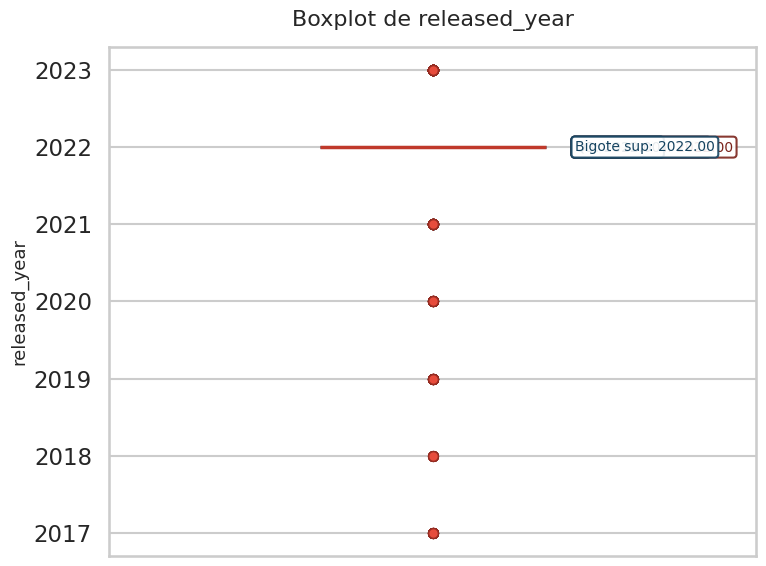

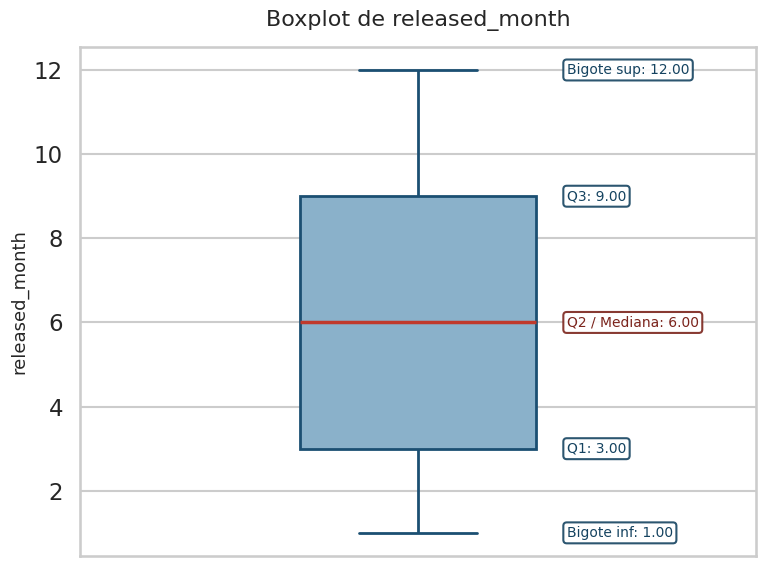

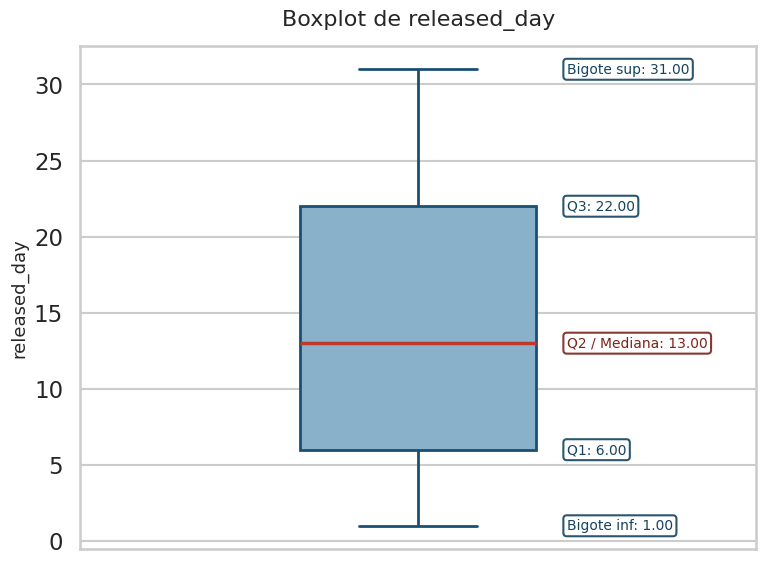

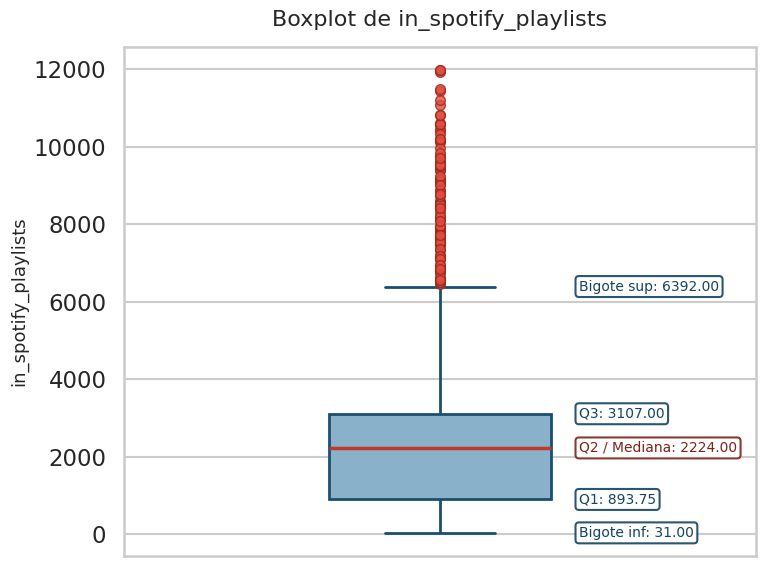

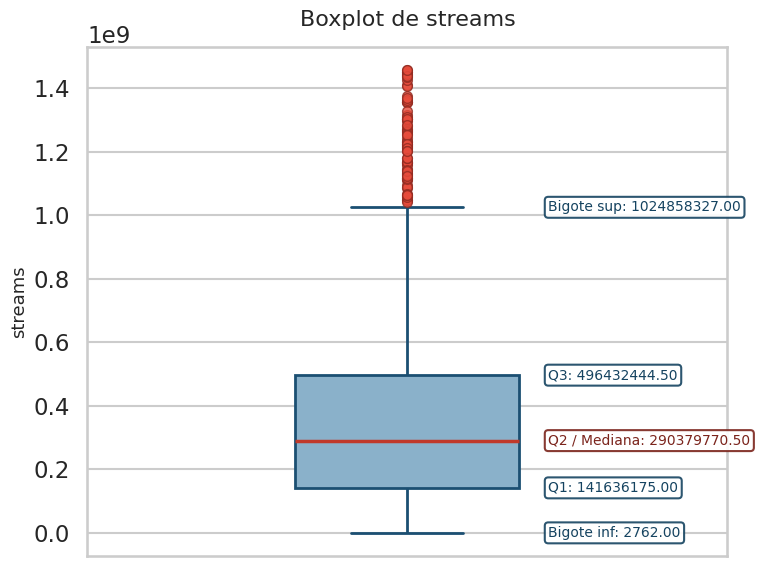

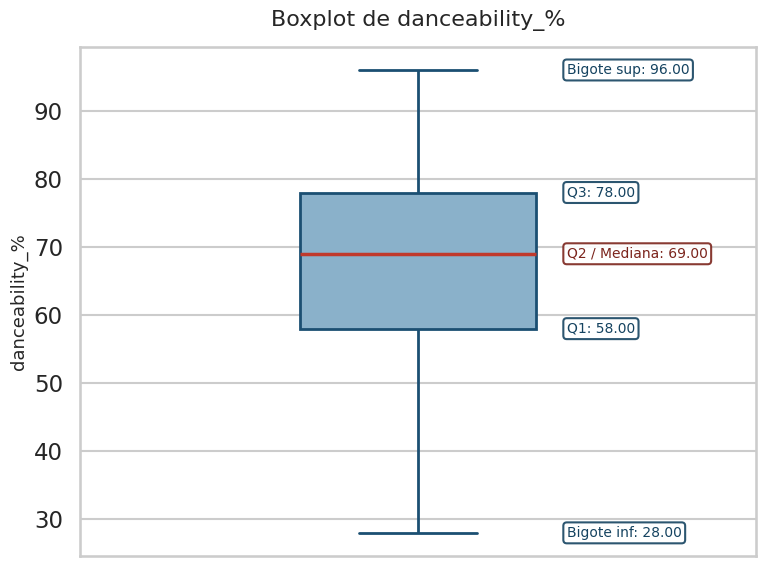

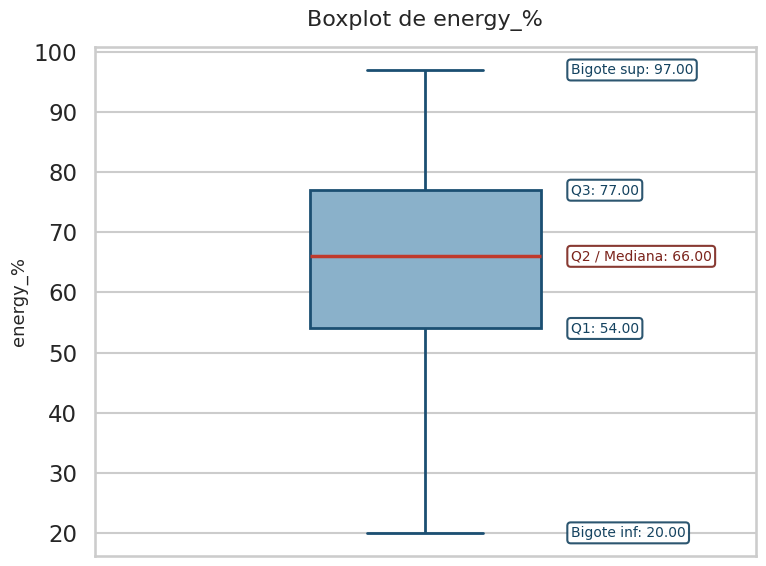

In [80]:
# Deteccion de outliers para todas las columnas

# 1. Identificamos automáticamente todas las columnas numéricas
# Esto evita errores al intentar procesar nombres de artistas o canciones
columnas_numericas = df_limpio.select_dtypes(include=['number']).columns.tolist()

for col in columnas_numericas:
    # 2. Convertimos a numérico por seguridad (maneja posibles errores de formato)
    df_limpio[col] = pd.to_numeric(df_limpio[col], errors='coerce')

    # 3. Si hay valores nulos tras la conversión, los llenamos con la mediana
    # para que el cálculo del IQR no falle
    if df_limpio[col].isnull().any():
        df_limpio[col] = df_limpio[col].fillna(df_limpio[col].median())

    # 4. Aplicamos la función de limpieza (IQR y reemplazo por mediana)
    df_limpio = tratar_outliers_iqr(df_limpio, col)

    # 5. Mostramos el gráfico final de la columna tratada
    boxplot_con_estadisticos(df_limpio, col)

In [81]:
# 1. Calculamos estadisticas antes y despues del tratamiento
resumen = pd.DataFrame({
    "Tipo de dato": df_limpio.dtypes,
    "Cantidad de nulos": df_limpio.isnull().sum(),
    # La media nos dice hacia donde se movio el centro de los datos
    "Media ": df_limpio.select_dtypes(include=['number']).mean().round(2),
    # La desviacion estandar nos dice cuanto se redujo la dispersion
    "Desv. Estandar": df_limpio.select_dtypes(include=['number']).std().round(2),
    "Mediana": df_limpio.select_dtypes(include=['number']).median().round(2)
})

# 2. Mostramos la tabla
display(resumen)

,Tipo de dato,Cantidad de nulos,Media,Desv. Estandar,Mediana
danceability_%,float64,0,6.727000e+01,1.407000e+01,69.0
energy_%,int64,0,6.449000e+01,1.623000e+01,66.0
in_spotify_playlists,float64,0,2.640730e+03,2.434800e+03,2224.0
key,object,0,NaN,NaN,NaN
mode,object,0,NaN,NaN,NaN
released_day,int64,0,1.394000e+01,9.200000e+00,13.0
released_month,int64,0,6.040000e+00,3.560000e+00,6.0
released_year,int64,0,2.021700e+03,1.220000e+00,2022.0
streams,int64,0,3.790285e+08,3.341686e+08,290379770.5
track_name,object,0,NaN,NaN,NaN


Explicacion de lo ocurrido:

Al utilizar el método de Rango Intercuartílico (IQR) y el ingreso de la mediana en los espacios vacios, se observan una serie de cambios en la distribucion de datos:

1. Reducción del Sesgo: Antes de hacer los calculos, columnas como streams presentaban una distribución con una inclinacion muy fuerte hacia la derecha debido a su fama, pero al remplazar estos valores atipicos por la mediana, la distribución ahora es mas uniforme, permitiendo que la media se posicione cerca del centro de los datos.

2. Estabilidad de las Variables: La Desviacion Estandar ahora es menor, en comparacion con los datos originales, esto indica que los datos ahora son mas homogeneos y mas uniformes, eliminando la distancia de los valores muy altos.

3. Cercania de medidas de tendecia central: Como se puede observar en la tabla de resumen, la media y la mediana ahora presentan valores mas cercanos. lo que nos da una prueba de que la distribución ha pasado de ser asimetrica a ser una distribución mas equilibrada y normalizada.

4. Normalizacion de Rangos: En el caso de released_year, el calculo redujo la dispersión de los outliers los cuales son los  años mas antiguos, centrando el dataset en estrenos recientes, lo que se refleja en una desviacion estandar (disperción de datos) muy baja (1.22).

Conclusion: El dataset ahora nos muestra un resultado mas preciso de la situacion. Los analisis anteriores como  los promedios no se veran distorsionados por casos muy alejados de los demas datos, mostrando de manera mas real el comportamiento general de las canciones en la plataforma durante 2023.

## 4. Codificación de variables categóricas

### Transformé las variables categóricas key (tonos musicales) y mode (minor o major) a un tipo de datos numérico a traves de la codificación (One Hot Encoding y Label Encoding). Esto permite que la información sea mas facil de trabajar por parte del computador.

In [82]:
# 1. Reemplazamos los infinitos por nulos
import pandas as pd

df_limpio.replace([float('inf'), float('-inf')], pd.NA, inplace=True)

# 2. Imputar nulos con la mediana
# Usamos numeric_only=True para que Pandas sepa que solo debe calcular la mediana
df_encoded = df_limpio.fillna(df_limpio.median(numeric_only=True))

# 3. Verificación
print(f"Nulos restantes: {df_encoded.isnull().sum().sum()}")

Nulos restantes: 0


In [83]:
# Funciones de codificacion

def aplicar_one_hot(df, columna):
    # pd.get_dummies es la forma nativa de Pandas para One Hot Encoding
    # prefix ayuda a identificar de qué columna vienen los 0 y 1
    dummies = pd.get_dummies(df[columna], prefix=columna)

    # Concatenamos las nuevas columnas y eliminamos la original
    df_out = pd.concat([df.drop(columns=[columna]), dummies], axis=1)
    return df_out

def aplicar_label_encoding(df, columna):
    df_out = df.copy()
    # Creamos un mapeo automático: cada categoría única recibe un número
    categorias = df_out[columna].unique()
    mapping = {categoria: i for i, categoria in enumerate(categorias)}

    # Aplicamos el mapeo a la columna
    df_out[columna] = df_out[columna].map(mapping)
    return df_out

# Ejecuccion

# 1. Aplicamos Label Encoding a mode
df_final = aplicar_label_encoding(df_encoded, "mode")

# 2. Aplicamos One Hot Encoding a key
df_final = aplicar_one_hot(df_final, "key")

# Ver el resultado final
display(df_final.head())

,track_name,released_year,released_month,released_day,in_spotify_playlists,streams,mode,danceability_%,energy_%,key_A,key_A#,key_B,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#
0,Seven (feat. Latto) (Explicit Ver.),2023,7,14,553.0,141381703,0,80.0,83,False,False,True,False,False,False,False,False,False,False,False
1,LALA,2023,3,23,1474.0,133716286,0,71.0,74,False,False,False,True,False,False,False,False,False,False,False
2,vampire,2023,6,30,1397.0,140003974,0,51.0,53,False,False,False,False,False,False,False,True,False,False,False
3,Cruel Summer,2019,8,23,7858.0,800840817,0,55.0,72,True,False,False,False,False,False,False,False,False,False,False
4,WHERE SHE GOES,2023,5,18,3133.0,303236322,1,65.0,80,True,False,False,False,False,False,False,False,False,False,False


In [84]:
# 1. Buscamos la moda
valor_moda = df_encoded['key'].mode()[0]

# 2. Rellenamos los huecos vacíos con esa moda
df_encoded['key'] = df_encoded['key'].fillna(valor_moda)

# 3. Ahora que no hay vacíos, aplicamos las funciones del profe
df_final = aplicar_label_encoding(df_encoded, "mode")
df_final = aplicar_one_hot(df_final, "key")

# 4. Verificamos que ahora sí cada fila tenga un True
print("Conteo de notas (el total de canciones):")
print(df_final.filter(like='key_').sum().sum())

Conteo de notas (el total de canciones):
952


In [85]:
# Cantidad de canciones que hay por cada una de las nota despues de la codificacion
print(df_final.filter(like='key_').sum())

key_A      74
key_A#     57
key_B      81
key_C#    215
key_D      81
key_D#     33
key_E      62
key_F      89
key_F#     73
key_G      96
key_G#     91
dtype: int64


In [86]:
import pandas as pd

# Se crea un pequeño resumen del estado del dataset
resumen_data = {
    "Etapa": ["Carga del dataset","Limpieza de datos","Tratamiento de outliers","Codificación de variables categóricas"],
    "Estado del Dataset": [
        "952 filas / Columnas originales",
        "0 valores nulos (Imputación mediana/moda)",
        "Distribución normalizada (Método IQR)",
        "Transformación categórica (One-Hot y Label Encoding)"
    ]
}

df_resumen = pd.DataFrame(resumen_data)

# Se muestra la tabla
display(df_resumen)

,Etapa,Estado del Dataset
0,Carga del dataset,952 filas / Columnas originales
1,Limpieza de datos,0 valores nulos (Imputación mediana/moda)
2,Tratamiento de outliers,Distribución normalizada (Método IQR)
3,Codificación de variables categóricas,Transformación categórica (One-Hot y Label Enc...


In [87]:
df_final.to_excel("spotify_limpio.xlsx", index=False)

Justificacion:

Para que el modelo de datos pueda procesar la información de Spotify, transforme las variables de texto en números de la siguiente manera:

1. One Hot Encoding (para la variable key)
Las notas musicales (A, B, C#, etc.) son categorías nominales. Esto significa que no hay una nota mejor, esto permite crear una columna para cada nota, si la canción tiene esa nota, pone True (1), en el otro caso marca False (0), esto ayuda a evitar que la computadora  tenga un jerarquia mala de las notas musicales.

2. Label Encoding (para la variable mode)
El modo musical solo tiene dos opciones Major y Minor. Esto Asigna un número fijo a cada categoría  Major = 0 y Minor = 1, esto lo hace un método más simple para variables con pocas opciones, ya que, mantiene el dataset ligero.

3. Los valores True (1) dice que si cumple con esa caracteristica y un False (0) indica que no la cumple, esto se deve a que las computadoras no saben leer palabras, pero son buenas procesando binarios. Al convertir el texto a binario el dataset queda listo para cálculos estadísticos.

Dataset ya está listo para
análisis. Porque se han eliminado los valores nulos y los datos muy alejados (outliers), garantizando que los calculos se hagan de una mejor manera, además las variables categóricas ya están pasadas al formato numerico (codificacion), permitiendo que cualquier algoritmo procese la información de una buena manera.